In [17]:
from pathlib import Path

def findProjectRoot(startPath):
    for parent in [startPath] + list(startPath.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Project root not found")

projectRoot = findProjectRoot(Path.cwd())
srcPath = projectRoot / "src"

if str(srcPath) not in sys.path:
    sys.path.append(str(srcPath))

import data

In [25]:
rootFilePath = str(projectRoot / "data" / "Waveforms_ds3803_run_Ds3803_Cal_Ch0158.root")

data.printRootBranches(rootFilePath, 'wforms')


Branches in tree 'wforms':

Channel                        int32_t
Dataset                        int32_t
Energy                         double
Multiplicity                   int32_t
TotalEnergy                    double
Run                            int32_t
Time                           double
M1                             bool
M2                             bool
NPulses                        int32_t
PSA_MDist                      double
Baseline                       double
BaselineSlope                  double
BaselineRMS                    double
Amplitude                      double
Waveform                       std::vector<double>


In [6]:
data.rootBranchesToHdf5(
    rootFile='/data/Waveforms_ds3803_run_Ds3803_Cal_Ch0158.root',
    treeName='wforms',
    branchList=['Waveform', 'Energy', 'NPulses'],
    hdf5File='/global/u2/v/vsharma2/Neutrino2026/data/testOutput.h5',
    entryStart=0,
    entryStop=1000
)

Error converting ROOT file '/data/Waveforms_ds3803_run_Ds3803_Cal_Ch0158.root': file not found

    '/data/Waveforms_ds3803_run_Ds3803_Cal_Ch0158.root'

Files may be specified as:
   * str/bytes: relative or absolute filesystem path or URL, without any colons
         other than Windows drive letter or URL schema.
         Examples: "rel/file.root", "C:\abs\file.root", "http://where/what.root"
   * str/bytes: same with an object-within-ROOT path, separated by a colon.
         Example: "rel/file.root:tdirectory/ttree"
   * pathlib.Path: always interpreted as a filesystem path or URL only (no
         object-within-ROOT path), regardless of whether there are any colons.
         Examples: Path("rel:/file.root"), Path("/abs/path:stuff.root")

Functions that accept many files (uproot.iterate, etc.) also allow:
   * glob syntax in str/bytes and pathlib.Path.
         Examples: Path("rel/*.root"), "/abs/*.root:tdirectory/ttree"
   * dict: keys are filesystem paths, values are objects-within

Inspecting entries [40, 72, 92, 23, 6, 17, 43, 51, 3] in /global/u2/v/vsharma2/Neutrino2026/data/testOutput.h5

===== Entry 40 =====
Energy:
  shape of dataset = (1000,)
  dtype = float64
  value = 1175.915237461415

NPulses:
  shape of dataset = (1000,)
  dtype = int32
  value = 1

Waveform:
  shape of dataset = (1000, 10000)
  dtype = float64
  entry shape = (10000,)
  first few values = [-63894. -63896. -63894. -63897. -63903. -63904. -63902. -63896. -63890.
 -63883.]

===== Entry 72 =====
Energy:
  shape of dataset = (1000,)
  dtype = float64
  value = 508.6039882895455

NPulses:
  shape of dataset = (1000,)
  dtype = int32
  value = 1

Waveform:
  shape of dataset = (1000, 10000)
  dtype = float64
  entry shape = (10000,)
  first few values = [-64055. -64060. -64062. -64064. -64066. -64069. -64074. -64074. -64071.
 -64070.]

===== Entry 92 =====
Energy:
  shape of dataset = (1000,)
  dtype = float64
  value = 508.90835822312135

NPulses:
  shape of dataset = (1000,)
  dtype = int3

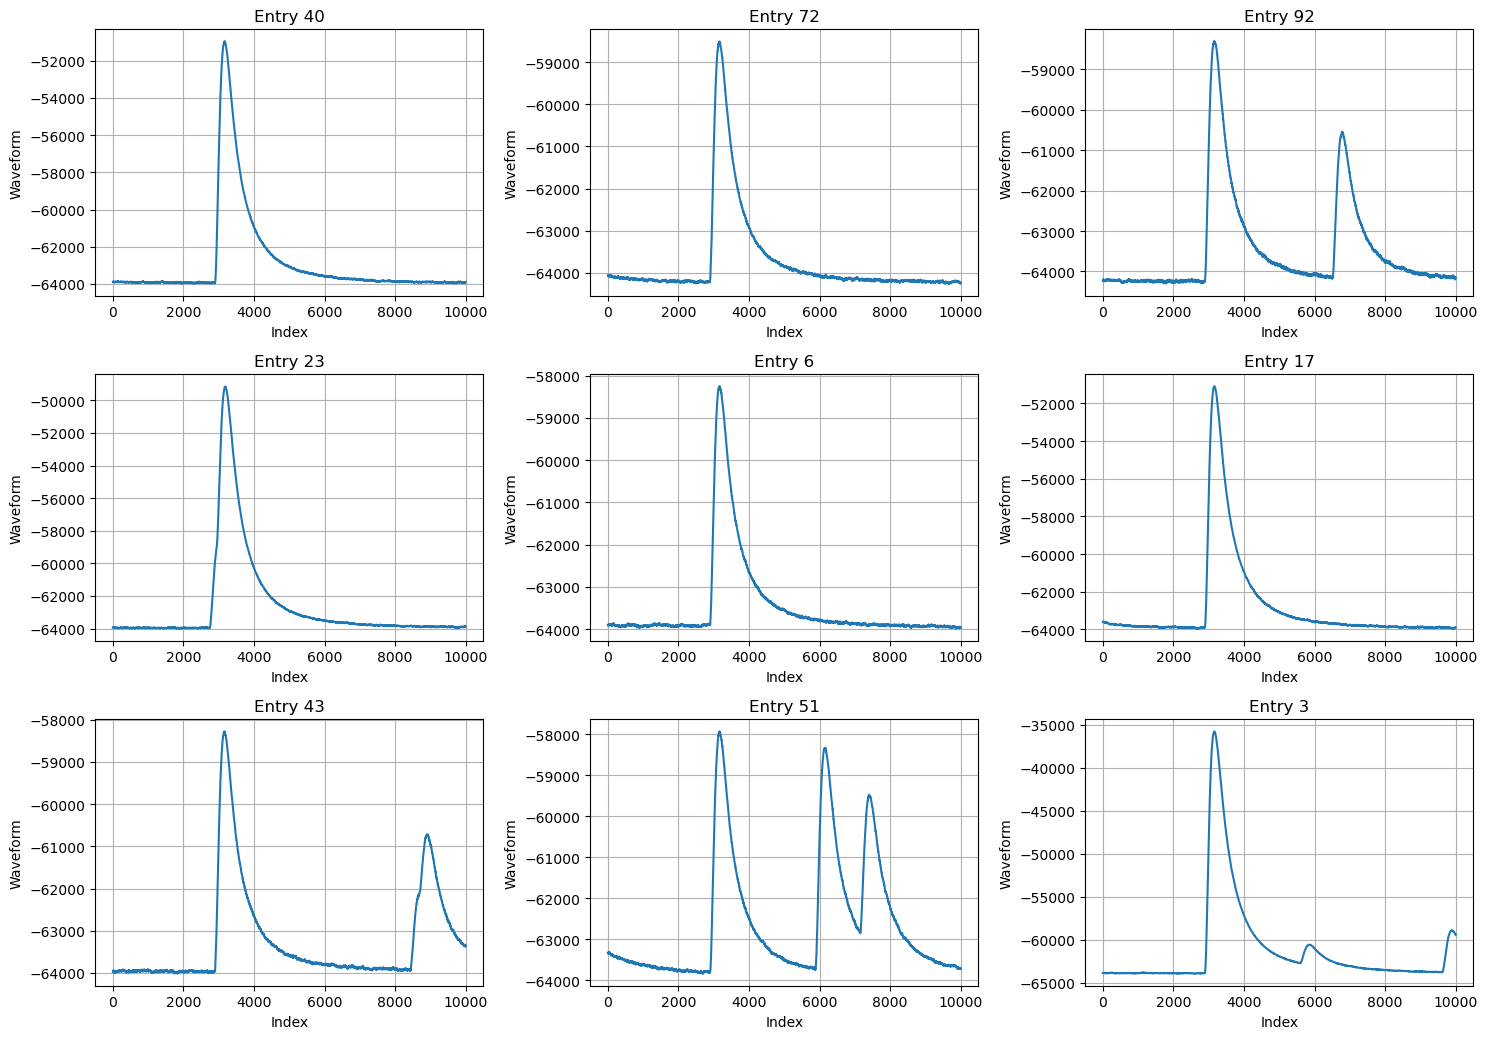

In [26]:
h5FilePath = str(projectRoot / "data" / "testOutput.h5")
data.inspectHdf5Entry(h5FilePath, entryIndex=[40,72,92,23,6,17,43,51,3], plotBranch='Waveform', xValues=None, maxCols=3)